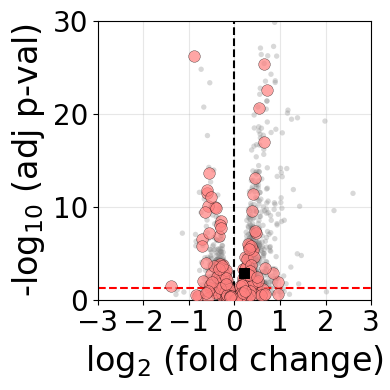

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

# Load data
df1 = pd.read_csv('/../../Data/Figure_5/sequencing_data_all.csv')

# Identify columns for reps 1-3
lfc_cols = sorted([c for c in df1.columns if c.startswith('log2FoldChange_rep') and c[-1] in ['1', '2', '3']])
se_cols  = sorted([c for c in df1.columns if c.startswith('lfcSE_rep')          and c[-1] in ['1', '2', '3']])

lfc_data = df1[lfc_cols].values
se_data  = df1[se_cols].values

weights = 1 / (se_data ** 2)
df1['weighted_log2FC'] = np.nansum(weights * lfc_data, axis=1) / np.nansum(weights, axis=1)
df1['pooled_SE']       = 1 / np.sqrt(np.nansum(weights, axis=1))
df1['z_score']         = df1['weighted_log2FC'] / df1['pooled_SE']
df1['pvalue']          = 2 * stats.norm.sf(np.abs(df1['z_score']))

_, df1['padj'], _, _ = multipletests(df1['pvalue'], method='fdr_bh')
df1['neg_log10_padj'] = -np.log10(df1['padj'].replace(0, 1e-300))

# Template 6 = index 5 in row_order
row_order = [
    'syn_LEA_1', 'At2g46140_tile7', 'TgL_8x', 'Os_LEA_or3__Kappa_up_2_',
    'CAHS_68135_tile4', 'A0A438HAK2', 'Asyn_isoform_5', 'A0A1U8F7A1',
    'Os_LEA_or6', 'Os_LEA_or4', 'A0A4D6M434',
]

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    return LinearSegmentedColormap.from_list(
        f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
        cmap(np.linspace(minval, maxval, n)))

truncated_spring = truncate_colormap(plt.cm.spring, 0.10, 0.90)
colors = {o: truncated_spring(i / (len(row_order) - 1)) for i, o in enumerate(row_order)}

# --- Template 6 ---
idx    = 5
origin = row_order[idx]

variants   = df1[df1['base_origin'] == origin].copy()
background = df1[df1['base_origin'] != origin].copy()
wt_id      = f'original_sequence_-_{origin}'
wt         = df1[df1['Sequence_ID'] == wt_id].copy()

fig, ax = plt.subplots(figsize=(4, 4))

ax.scatter(background['weighted_log2FC'], background['neg_log10_padj'],
           alpha=0.3, s=15, c='gray', edgecolors='none', zorder=1)
ax.scatter(variants['weighted_log2FC'], variants['neg_log10_padj'],
           alpha=0.7, s=70, c=[colors[origin]], edgecolors='k',
           linewidths=0.3, zorder=5)

if len(wt):
    ax.scatter(wt['weighted_log2FC'], wt['neg_log10_padj'],
               alpha=1.0, s=60, c='black', edgecolors='k',
               linewidths=0.5, marker='s', zorder=10)

ax.axhline(y=-np.log10(0.05), color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=0, color='k', linestyle='--', linewidth=1.5)

ax.set_xlabel('log$_2$ (fold change)', fontsize=24)
ax.set_ylabel('-log$_{10}$ (adj p-val)', fontsize=24)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 30)
ax.set_xticks([-3, -2, -1, 0, 1, 2, 3])
ax.tick_params(axis='both', which='major', labelsize=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
#plt.savefig('volcano_template6.svg', format='svg', bbox_inches='tight')
#plt.savefig('volcano_template6.png', format='png', bbox_inches='tight', dpi=300)
plt.show()